# **Chuẩn bị thư viện khởi tạo**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import glob
import plotly.express as px
import plotly.graph_objects as go

# visualization l ibraries
import matplotlib.colors as colors
import plotly.express as px

sns.set(style="whitegrid")

plt.style.use("default")

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white"
})


# **Nhập dữ liệu**

In [ ]:
tiktok_condao = pd.read_excel("TikTok_ConDao.xlsx")
tiktok_catba = pd.read_excel("tiktok_Cat_Ba (1).xlsx")
tiktok_phuquoc = pd.read_excel("tiktok_PhuQuoc.xlsx")
tiktok_comment = pd.read_excel("tiktokcomment.xlsx")

ytb_catba = pd.read_excel("ytb_CatBa.xlsx")
ytb_condao = pd.read_excel("ytb_ConDao.xlsx")
ytb_phuquoc = pd.read_excel("ytb_PhuQuoc.xlsx")
ytb_comment = pd.read_excel("ytbcomment.xlsx")

# **Định dạng dữ liệu - bảng**

In [ ]:
#Viết thường, thay dấu cách bằng gạch dưới, xóa khoảng trắng thừa
def normalize_columns(df):
    new_columns = {col: col.lower().replace(' ', '_').replace('-', '_').strip() for col in df.columns}
    return df.rename(columns=new_columns)
#Đảm bảo các cột thống nhất giữa TikTok và YouTube để gộp chung
def ensure_common_columns(df, platform):
    df = normalize_columns(df)
# Bản đồ ánh xạ cột từ các file gốc về tên chung
    mapping = {
        'viewcount': 'view',
        'likes': 'like',
        'channelname': 'author_name',
        'title': 'caption',
        'date': 'create_time'
    }
    df = df.rename(columns=mapping)
    common_cols = [
        "author_name", "caption", "view", "like", "share",
        "comment", "save", "duration", "create_time"
    ]

    for col in common_cols:
        if col not in df.columns:
            df[col] = 0 if col in ['view', 'like', 'share', 'comment', 'save'] else ""
    df["duration"] = pd.to_numeric(df["duration"], errors="coerce")

    df['platform'] = platform

    return df[common_cols + ['platform']]
# Chuẩn hóa từng DataFrame
df_tt_cb = ensure_common_columns(tiktok_catba, 'TikTok')
df_tt_cd = ensure_common_columns(tiktok_condao, 'TikTok')
df_tt_pq = ensure_common_columns(tiktok_phuquoc, 'TikTok')

df_yt_cb = ensure_common_columns(ytb_catba, 'YouTube')
df_yt_cd = ensure_common_columns(ytb_condao, 'YouTube')
df_yt_pq = ensure_common_columns(ytb_phuquoc, 'YouTube')

# **Gộp dữ liệu & Tính toán**

In [ ]:
import pandas as pd
import os
import re

def clean_num(val):
    if pd.isna(val) or val == '': return 0.0
    if isinstance(val, (int, float)): return float(val)
    val = str(val).lower().strip().replace(',', '')
    mult = 1
    if 'k' in val: mult = 1000; val = val.replace('k', '')
    if 'm' in val: mult = 1000000; val = val.replace('m', '')
    try:
        res = re.search(r'(\d+\.?\d*)', val)
        return float(res.group(1)) * mult if res else 0.0
    except:
        return 0.0

def get_loc(f):
    f = f.lower()
    if 'phuquoc' in f: return 'Phu Quoc'
    if 'catba' in f or 'cat_ba' in f: return 'Cat Ba'
    return 'Con Dao'

ytb_posts = ['ytb_PhuQuoc.xlsx', 'ytb_CatBa.xlsx', 'ytb_ConDao.xlsx']
tk_posts = ['tiktok_PhuQuoc.xlsx', 'tiktok_Cat_Ba (1).xlsx', 'TikTok_ConDao.xlsx']

all_posts = []

final_cols = [
    'Location', 'Platform', 'Created_At', 'Duration', 'Views', 'Likes', 'Shares',
    'Comments', 'Saves', 'Total_Engagement', 'Engagement_Rate', 'Content_Full'
]

for f in ytb_posts + tk_posts:
    if os.path.exists(f):
        is_tk = 'tiktok' in f.lower()
        df = pd.read_excel(f, skiprows=1 if is_tk else 0)
        df.columns = [c.strip().lower() for c in df.columns]

        # --- XỬ LÝ Created_At AN TOÀN ---
        if 'date' in df.columns:
            # Chuyển đổi và loại bỏ múi giờ ngay lập tức
            df['Created_At'] = pd.to_datetime(df['date'], errors='coerce').dt.tz_localize(None)
        elif 'create_time' in df.columns:
            df['Created_At'] = pd.to_datetime(df['create_time'], errors='coerce').dt.tz_localize(None)
        else:
            df['Created_At'] = pd.NaT

        # --- XỬ LÝ NỘI DUNG ---
        if 'content_text' in df.columns:
            df['Content_Full'] = df['content_text'].fillna(df.get('caption', '')).fillna('')
        elif 'context_text' in df.columns:
            df['Content_Full'] = df['context_text'].fillna(df.get('caption', '')).fillna('')
        else:
            df['Content_Full'] = df.get('caption', '')

        # --- DURATION & MAPPING ---
        df['Duration'] = df['duration'] if 'duration' in df.columns else 'N/A'
        mapping = {
            'viewcount': 'Views', 'view': 'Views', 'views': 'Views',
            'likes': 'Likes', 'like': 'Likes',
            'share': 'Shares', 'shares': 'Shares',
            'comment': 'Comments', 'comments': 'Comments',
            'save': 'Saves', 'saves': 'Saves'
        }
        df = df.rename(columns=mapping)
        df['Location'] = get_loc(f)
        df['Platform'] = 'TikTok' if is_tk else 'YouTube'

        for col in ['Views', 'Likes', 'Shares', 'Comments', 'Saves']:
            df[col] = df[col].apply(clean_num) if col in df.columns else 0.0

        df['Total_Engagement'] = df[['Likes', 'Shares', 'Comments', 'Saves']].sum(axis=1)
        df['Engagement_Rate'] = df.apply(
            lambda r: (r['Total_Engagement'] / r['Views'] * 100) if r['Views'] > 0 else 0, axis=1
        )

        all_posts.append(df[[c for c in final_cols if c in df.columns]])

if all_posts:
    df_final = pd.concat(all_posts, ignore_index=True)

    # --- FIX LỖI MIX TZ-AWARE/TZ-NAIVE ---
    # Chuyển đổi về datetime và đảm bảo không còn múi giờ để so sánh
    df_final['Created_At'] = pd.to_datetime(df_final['Created_At'], errors='coerce').dt.tz_localize(None)

    # Lọc dữ liệu từ 2024 đến 2026
    df_final = df_final[(df_final['Created_At'].dt.year >= 2024) & (df_final['Created_At'].dt.year <= 2026)]

    # Sắp xếp và xuất file
    df_final = df_final.sort_values(by='Created_At')
    df_final.to_csv('merged_data_fixed_date.csv', index=False, encoding='utf-8-sig')

    print(f"✅ Thành công! Đã xử lý {len(df_final)} dòng dữ liệu từ 2024-2026.")
    print(df_final[['Location', 'Created_At']].head())
else:
    print("❌ Không có dữ liệu.")

✅ Thành công! Đã xử lý 939 dòng dữ liệu từ 2024-2026.
      Location          Created_At
1039   Con Dao 2024-01-02 11:31:20
1750    Cat Ba 2024-01-10 05:23:29
1661    Cat Ba 2024-01-14 12:22:13
995    Con Dao 2024-01-17 12:36:53
267   Phu Quoc 2024-01-21 16:06:27


# **Thống kê nhanh**

In [ ]:
print("\n📊 BÁO CÁO TỔNG QUAN:")
summary_data = []
for loc, df in datasets.items():
    summary_data.append({
        "Địa điểm": loc,
        "Tổng bài đăng": len(df),
        "Tổng View": df['view'].sum(),
        "Tổng Engagement": df['total_engagement'].sum(),
        "ER Trung bình (%)": (df['engagement_rate'].mean() * 100)
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

# Ví dụ xem top bài đăng tại Phú Quốc
print("\n🔥 Top 5 bài đăng nhiều View nhất tại Phú Quốc:")
print(datasets["Phu Quoc"].nlargest(5, 'view')[['platform', 'author_name', 'view', 'total_engagement']])


📊 BÁO CÁO TỔNG QUAN:


NameError: name 'datasets' is not defined

# **Hiệu quả truyền thông theo địa điểm du lịch**

In [ ]:
locations = list(datasets.keys())
colors =["#3f5175", "#2f7f7a", "#73b86b"] # xanh - cam - xanh lá
total_views = [df["view"].sum() for df in datasets.values()]
plt.figure(figsize=(6,4))
plt.bar(locations, total_views, color=colors)
plt.title("Total Views by Location")
plt.xlabel("Location")
plt.ylabel("Total Views")

plt.show()


NameError: name 'datasets' is not defined

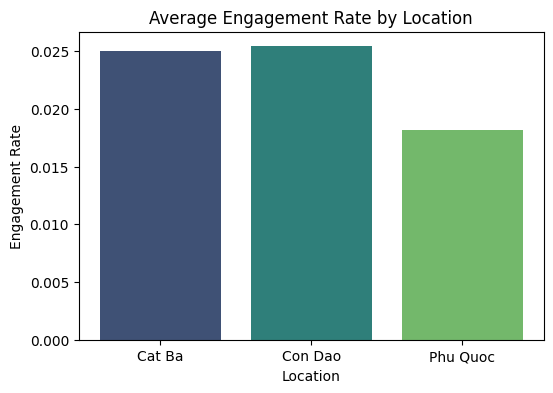

In [ ]:
avg_er = [df["engagement_rate"].mean() for df in datasets.values()]

plt.figure(figsize=(6,4))
plt.bar(locations, avg_er, color=colors)
plt.title("Average Engagement Rate by Location")
plt.xlabel("Location")
plt.ylabel("Engagement Rate")
plt.show()


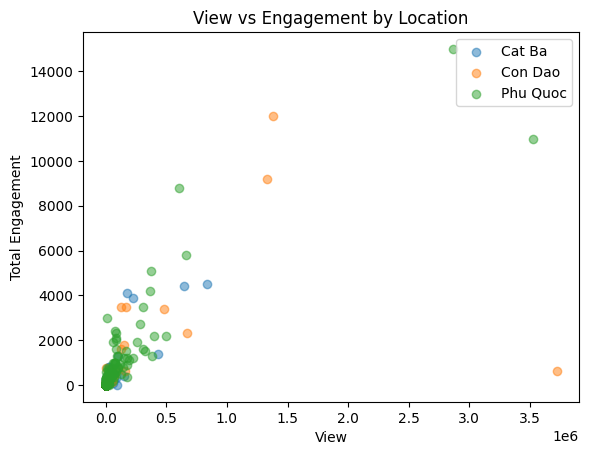

In [ ]:
plt.figure()

for loc, df in datasets.items():
    plt.scatter(df["view"], df["total_engagement"], label=loc, alpha=0.5)
plt.xlabel("View")
plt.ylabel("Total Engagement")
plt.title("View vs Engagement by Location")
plt.legend()
plt.show()


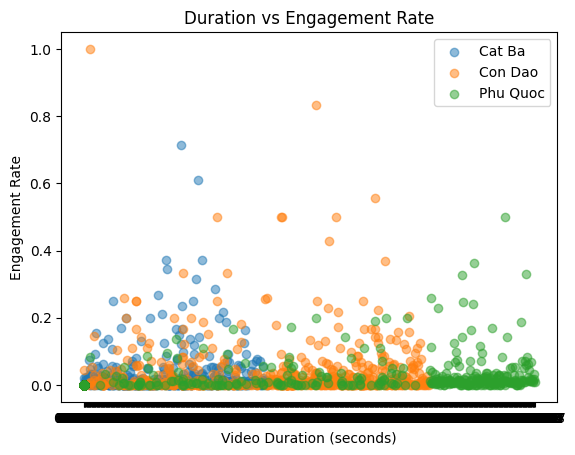

In [ ]:
plt.figure()

for loc, df in datasets.items():
    plt.scatter(df["duration"], df["engagement_rate"], label=loc, alpha=0.5)

plt.xlabel("Video Duration (seconds)")
plt.ylabel("Engagement Rate")
plt.title("Duration vs Engagement Rate")
plt.legend()
plt.show()


/tmp/ipykernel_750/3097420461.py:13: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Location', y='Total_Engagement', hue='Platform', ax=axes[0, 0], estimator=sum, ci=None)
/tmp/ipykernel_750/3097420461.py:18: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Location', y='Engagement_Rate', hue='Platform', ax=axes[0, 1], ci=None)


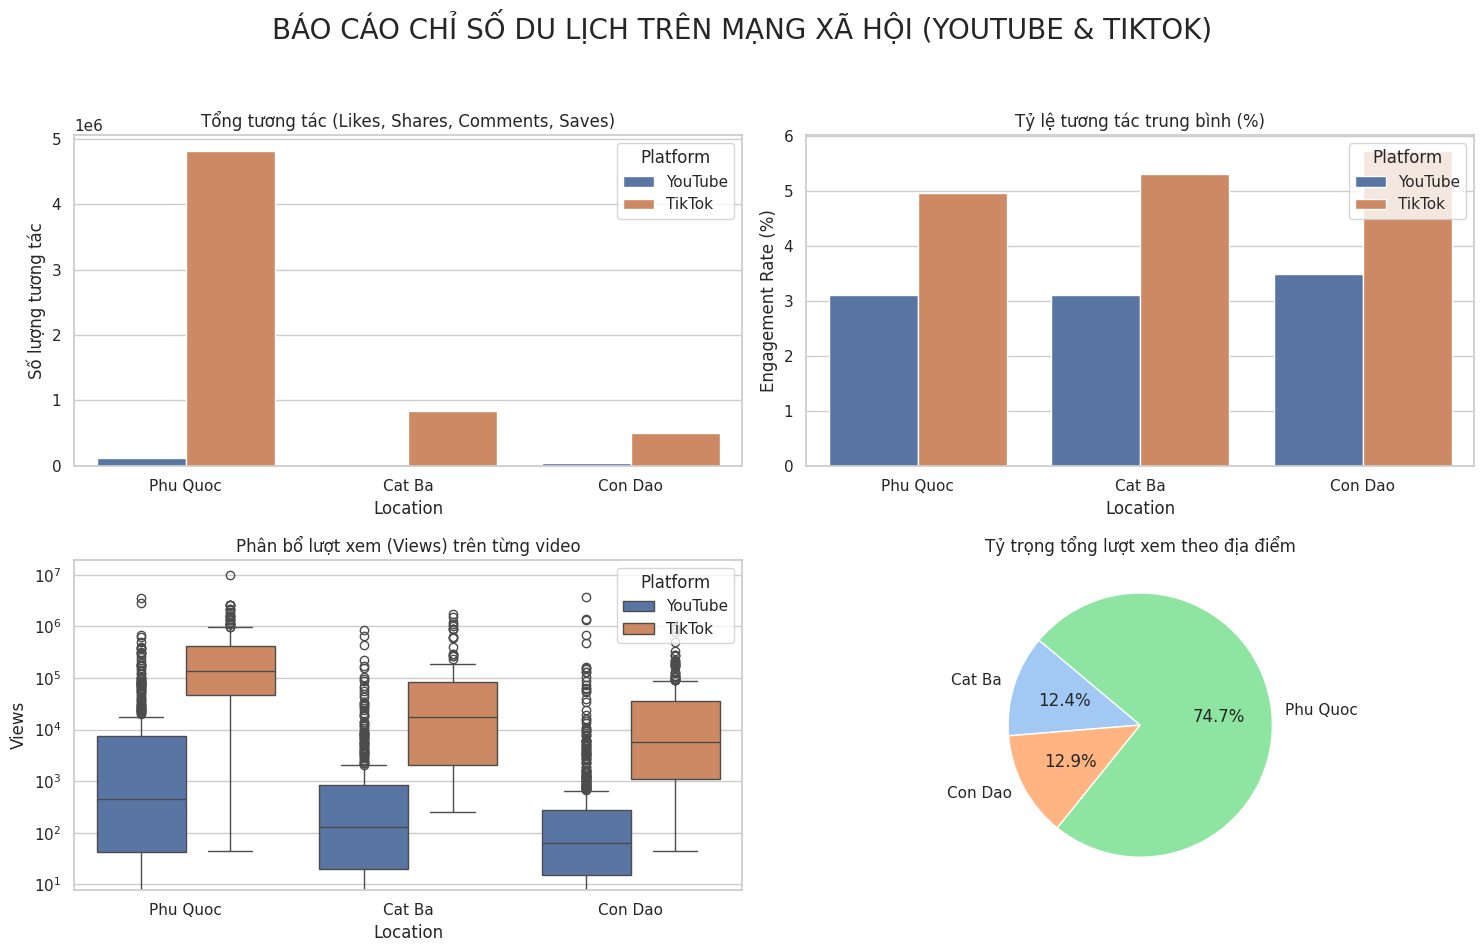

In [ ]:
# Đọc dữ liệu đã gộp
df = pd.read_csv('merged_data_final_report.csv')

# Thiết lập tiếng Việt và phong cách biểu đồ
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

# Tạo Dashboard 2x2
fig, axes = plt.subplots(2, 2)
fig.suptitle('BÁO CÁO CHỈ SỐ DU LỊCH TRÊN MẠNG XÃ HỘI (YOUTUBE & TIKTOK)', fontsize=20)

# 1. Biểu đồ: Tổng Engagement theo từng Địa điểm
sns.barplot(data=df, x='Location', y='Total_Engagement', hue='Platform', ax=axes[0, 0], estimator=sum, ci=None)
axes[0, 0].set_title('Tổng tương tác (Likes, Shares, Comments, Saves)')
axes[0, 0].set_ylabel('Số lượng tương tác')

# 2. Biểu đồ: Engagement Rate trung bình (Hiệu quả nội dung)
sns.barplot(data=df, x='Location', y='Engagement_Rate', hue='Platform', ax=axes[0, 1], ci=None)
axes[0, 1].set_title('Tỷ lệ tương tác trung bình (%)')
axes[0, 1].set_ylabel('Engagement Rate (%)')

# 3. Biểu đồ: Tổng Views theo Địa điểm
sns.boxplot(data=df, x='Location', y='Views', hue='Platform', ax=axes[1, 0])
axes[1, 0].set_title('Phân bổ lượt xem (Views) trên từng video')
axes[1, 0].set_yscale('log') # Dùng thang log nếu view quá chênh lệch

# 4. Biểu đồ tròn: Tỷ trọng Views giữa 3 địa điểm
loc_views = df.groupby('Location')['Views'].sum()
axes[1, 1].pie(loc_views, labels=loc_views.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
axes[1, 1].set_title('Tỷ trọng tổng lượt xem theo địa điểm')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

/tmp/ipykernel_750/3194035852.py:17: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Location', y='Views', hue='Platform', ax=axes[0, 0], estimator=sum, ci=None, palette='viridis')
/tmp/ipykernel_750/3194035852.py:23: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Location', y='Total_Engagement', hue='Platform', ax=axes[0, 1], estimator=sum, ci=None, palette='magma')


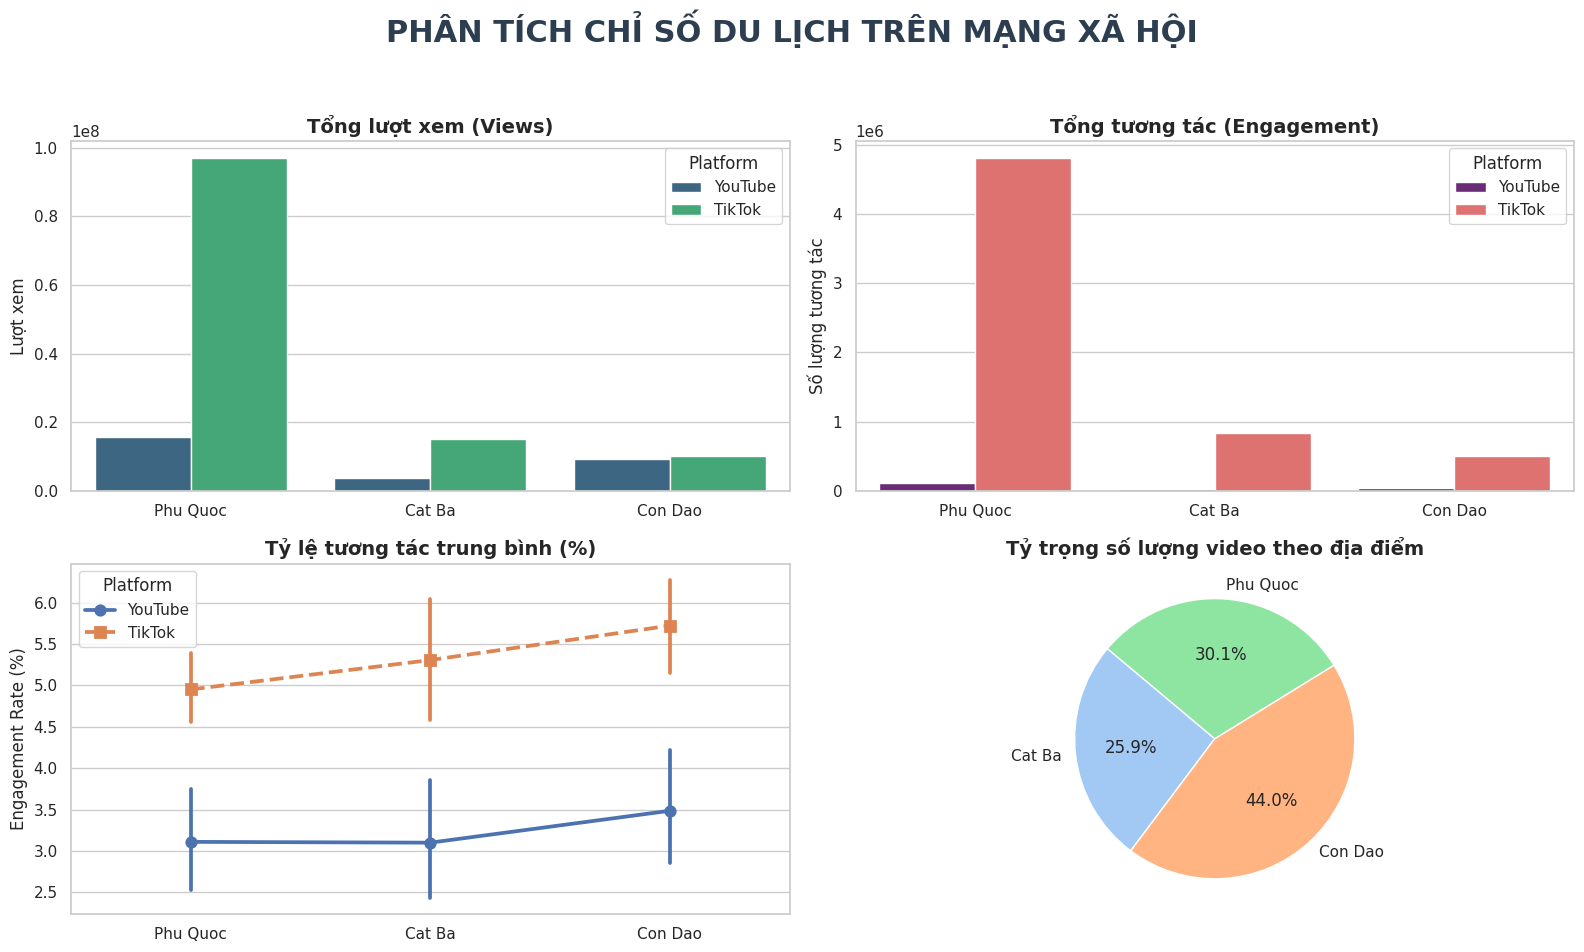

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Đọc dữ liệu
df = pd.read_csv('merged_data_final_report.csv')

# Thiết lập font và style (đảm bảo hỗ trợ tiếng Việt nếu cần)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (16, 10)

# 2. Khởi tạo bố cục Dashboard (2 hàng, 2 cột)
fig, axes = plt.subplots(2, 2)
fig.suptitle('PHÂN TÍCH CHỈ SỐ DU LỊCH TRÊN MẠNG XÃ HỘI', fontsize=22, fontweight='bold', color='#2c3e50')

# --- BIỂU ĐỒ 1: TỔNG LƯỢT XEM THEO ĐỊA ĐIỂM ---
sns.barplot(data=df, x='Location', y='Views', hue='Platform', ax=axes[0, 0], estimator=sum, ci=None, palette='viridis')
axes[0, 0].set_title('Tổng lượt xem (Views)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('')
axes[0, 0].set_ylabel('Lượt xem')

# --- BIỂU ĐỒ 2: TỔNG TƯƠNG TÁC (LIKES, SHARES, COMMENTS, SAVES) ---
sns.barplot(data=df, x='Location', y='Total_Engagement', hue='Platform', ax=axes[0, 1], estimator=sum, ci=None, palette='magma')
axes[0, 1].set_title('Tổng tương tác (Engagement)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('')
axes[0, 1].set_ylabel('Số lượng tương tác')

# --- BIỂU ĐỒ 3: HIỆU QUẢ NỘI DUNG (ENGAGEMENT RATE TRUNG BÌNH) ---
sns.pointplot(data=df, x='Location', y='Engagement_Rate', hue='Platform', ax=axes[1, 0], markers=["o", "s"], linestyles=["-", "--"])
axes[1, 0].set_title('Tỷ lệ tương tác trung bình (%)', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('')
axes[1, 0].set_ylabel('Engagement Rate (%)')

# --- BIỂU ĐỒ 4: TỶ TRỌNG THẢO LUẬN (DỰA TRÊN SỐ LƯỢNG BÀI ĐĂNG) ---
post_counts = df.groupby('Location').size()
axes[1, 1].pie(post_counts, labels=post_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
axes[1, 1].set_title('Tỷ trọng số lượng video theo địa điểm', fontsize=14, fontweight='bold')

# Tối ưu khoảng cách giữa các biểu đồ
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# 3. Lưu và hiển thị
plt.savefig('social_media_dashboard.png', dpi=300)
plt.show()

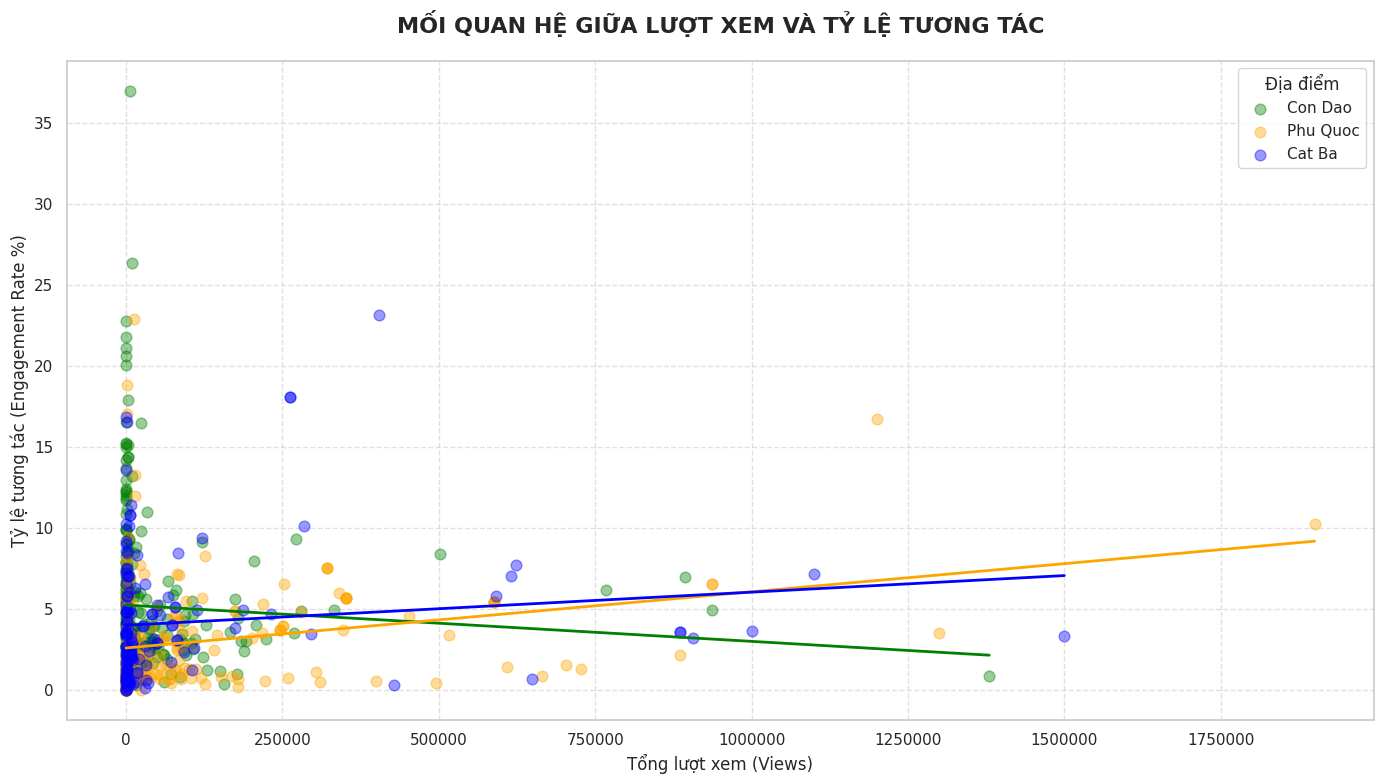

In [ ]:
# 1. Đọc dữ liệu
df = pd.read_csv('merged_data_fixed_date.csv')

# 2. Làm sạch dữ liệu (Lọc bỏ các giá trị nhiễu)
# Loại bỏ các video có 0 view hoặc tỉ lệ tương tác quá ảo (ví dụ > 100%)
df_clean = df[(df['Views'] > 100) & (df['Engagement_Rate'] < 30)]
# 3. Vẽ biểu đồ
plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

# Vẽ Scatter Plot phân loại theo màu sắc cho 3 địa điểm
# Sử dụng regplot để vẽ đường hồi quy cho từng nhóm
colors = {'Con Dao': 'green', 'Phu Quoc': 'orange', 'Cat Ba': 'blue'}

for loc, color in colors.items():
    subset = df_plot[df_plot['Location'] == loc]
    sns.regplot(
        data=subset,
        x='Views',
        y='Engagement_Rate',
        label=loc,
        color=color,
        scatter_kws={'alpha':0.4, 's':60}, # Độ trong suốt và kích thước điểm
        line_kws={'linewidth':2},
        ci=None # Tắt dải bóng tin cậy cho đỡ rối
    )

# 4. Tùy chỉnh hiển thị
plt.title('MỐI QUAN HỆ GIỮA LƯỢT XEM VÀ TỶ LỆ TƯƠNG TÁC', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Tổng lượt xem (Views)', fontsize=12)
plt.ylabel('Tỷ lệ tương tác (Engagement Rate %)', fontsize=12)

# Vì View thường có số lớn, ta có thể dùng định dạng số rút gọn
plt.ticklabel_format(style='plain', axis='x')

plt.legend(title='Địa điểm')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

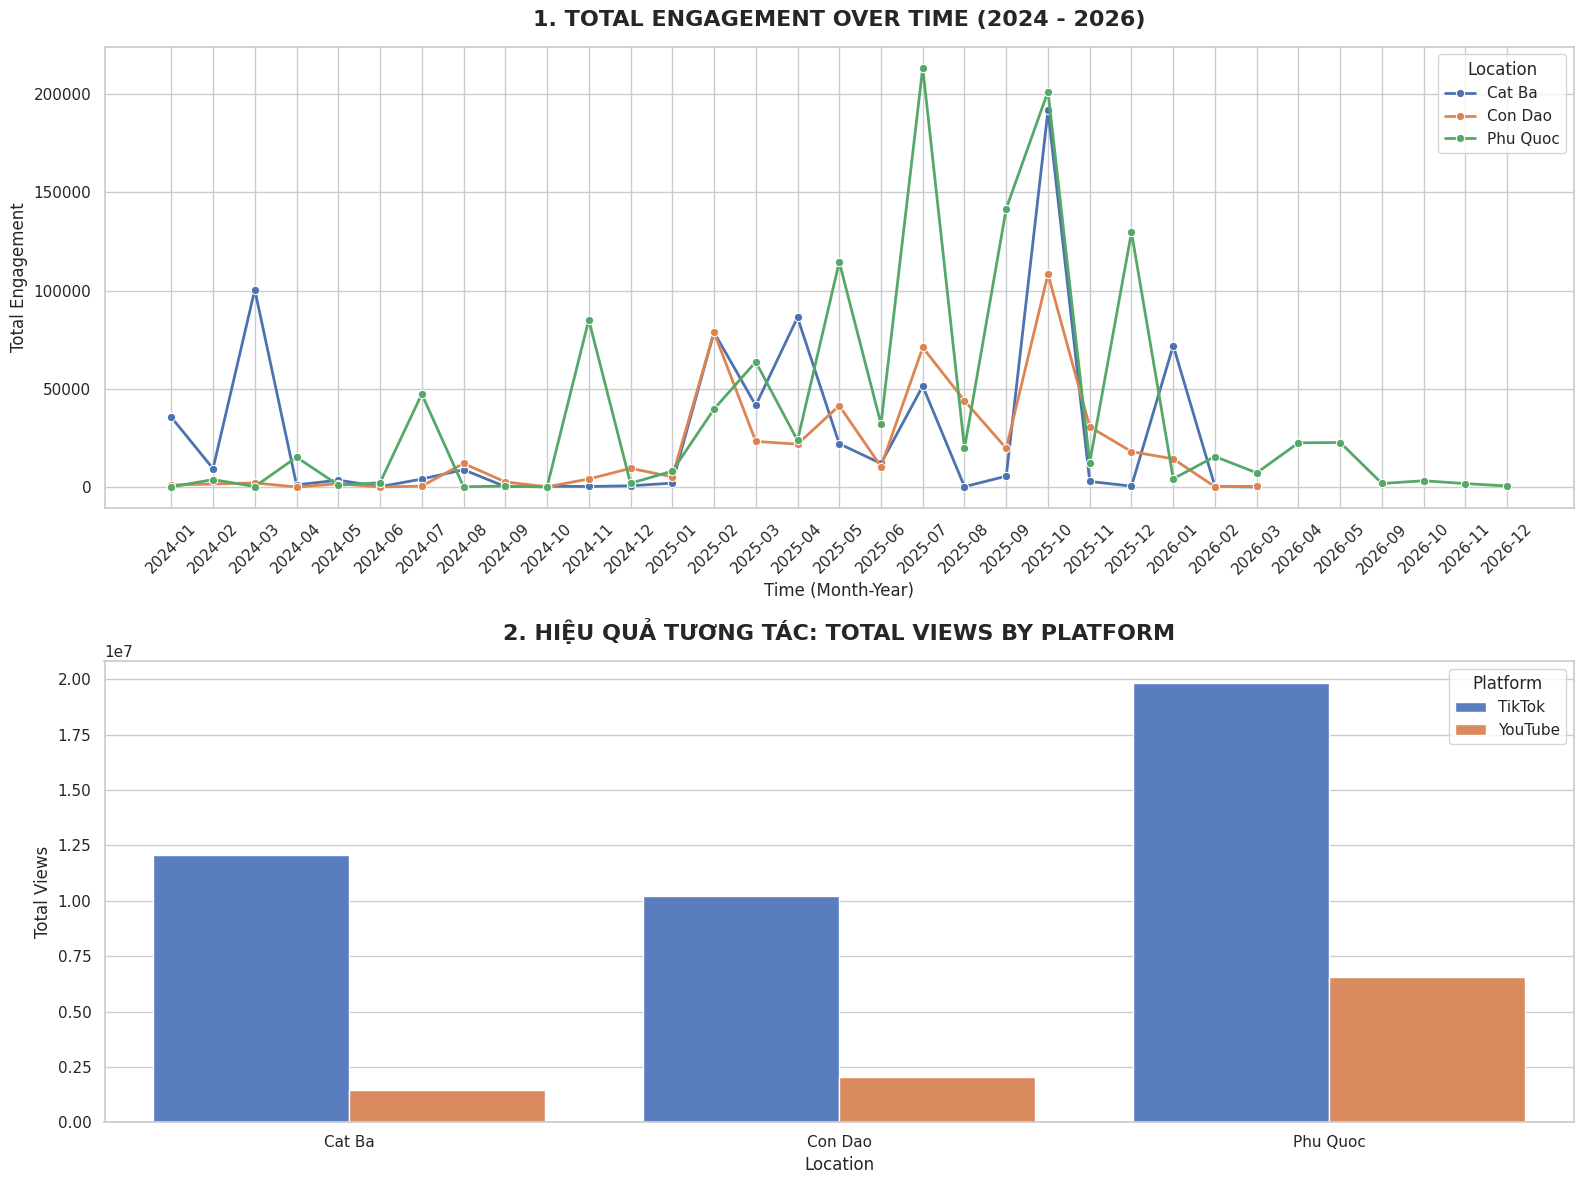

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Đọc dữ liệu đã xử lý Created_At thành công
df = pd.read_csv('merged_data_fixed_date.csv')
df['Created_At'] = pd.to_datetime(df['Created_At'])

# 2. Lọc chính xác giai đoạn 2024 - 2026
df_filtered = df[(df['Created_At'].dt.year >= 2024) & (df['Created_At'].dt.year <= 2026)].copy()

# Tạo cột Tháng-Năm để vẽ biểu đồ đường cho mượt
df_filtered['Month_Year'] = df_filtered['Created_At'].dt.to_period('M').astype(str)

# Thiết lập phong cách biểu đồ
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)

# Tạo khung Dashboard 2 hàng
fig, (ax1, ax2) = plt.subplots(2, 1)

# ---------------------------------------------------------
# BIỂU ĐỒ 1: TOTAL ENGAGEMENT OVER TIME (Line Chart)
# So sánh phong độ quảng bá của 3 địa điểm
# ---------------------------------------------------------
# Gom nhóm dữ liệu theo Tháng và Địa điểm
timeline_engagement = df_filtered.groupby(['Month_Year', 'Location'])['Total_Engagement'].sum().reset_index()

sns.lineplot(
    data=timeline_engagement,
    x='Month_Year',
    y='Total_Engagement',
    hue='Location',
    marker='o',
    linewidth=2,
    ax=ax1
)

ax1.set_title('1. TOTAL ENGAGEMENT OVER TIME (2024 - 2026)', fontsize=16, fontweight='bold', pad=15)
ax1.set_ylabel('Total Engagement')
ax1.set_xlabel('Time (Month-Year)')
ax1.tick_params(axis='x', rotation=45)

# ---------------------------------------------------------
# BIỂU ĐỒ 2: HIỆU QUẢ TƯƠNG TÁC TRUNG BÌNH (Grouped Bar Chart)
# So sánh thế mạnh YouTube (Video dài) vs TikTok (Video ngắn)
# ---------------------------------------------------------
# Tính lượt xem trung bình hoặc tổng theo từng nền tảng tại mỗi địa điểm
platform_comparison = df_filtered.groupby(['Location', 'Platform'])['Views'].sum().reset_index()

sns.barplot(
    data=platform_comparison,
    x='Location',
    y='Views',
    hue='Platform',
    ax=ax2,
    palette='muted'
)

ax2.set_title('2. HIỆU QUẢ TƯƠNG TÁC: TOTAL VIEWS BY PLATFORM', fontsize=16, fontweight='bold', pad=15)
ax2.set_ylabel('Total Views')
ax2.set_xlabel('Location')

# Tối ưu hóa hiển thị
plt.tight_layout()
plt.savefig('destination_comparison_2024_2026.png', dpi=300)
plt.show()

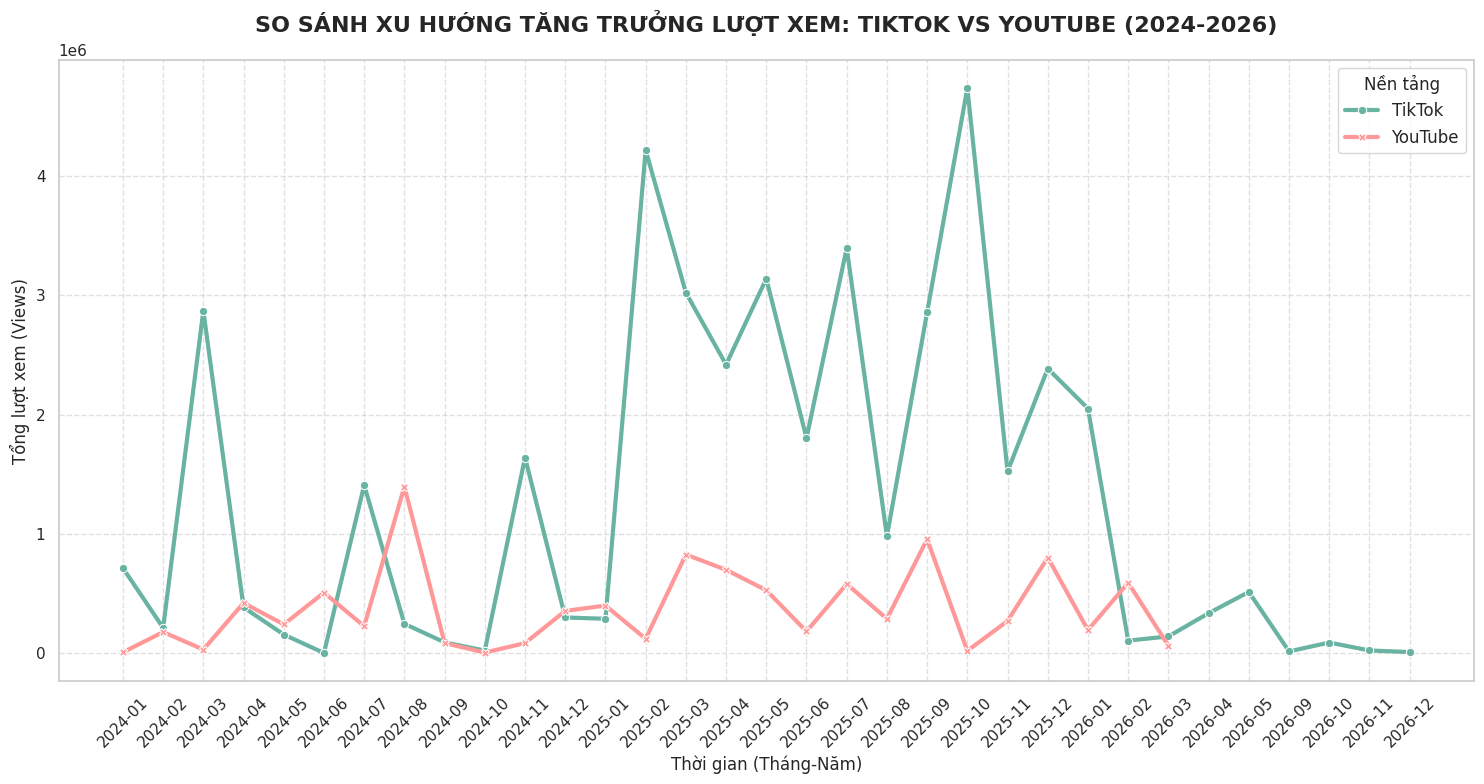

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Chuẩn bị dữ liệu
# Sử dụng file đã fix lỗi múi giờ và lọc mốc 2024-2026
df = pd.read_csv('merged_data_fixed_date.csv')
df['Created_At'] = pd.to_datetime(df['Created_At'])

# Gom nhóm theo Tháng và Nền tảng để thấy xu hướng tăng trưởng
# Chúng ta lấy tổng Views của mỗi nền tảng qua từng tháng
df['Month_Year'] = df['Created_At'].dt.to_period('M').astype(str)
growth_data = df.groupby(['Month_Year', 'Platform'])['Views'].sum().reset_index()

# 2. Thiết lập biểu đồ
plt.figure(figsize=(15, 8))
sns.set_theme(style="whitegrid")

# Vẽ đường xu hướng cho TikTok và YouTube
line_plot = sns.lineplot(
    data=growth_data,
    x='Month_Year',
    y='Views',
    hue='Platform',
    style='Platform',
    markers=True,
    dashes=False,
    linewidth=3,
    palette={'TikTok': '#69b3a2', 'YouTube': '#ff9999'} # Màu sắc đặc trưng
)

# 3. Định dạng biểu đồ để so sánh mùa vụ
plt.title('SO SÁNH XU HƯỚNG TĂNG TRƯỞNG LƯỢT XEM: TIKTOK VS YOUTUBE (2024-2026)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Thời gian (Tháng-Năm)', fontsize=12)
plt.ylabel('Tổng lượt xem (Views)', fontsize=12)

# Xoay nhãn trục X để không bị chồng lấp
plt.xticks(rotation=45)

# Thêm chú thích về mùa du lịch (Ví dụ: Thường là tháng 5-8 và tháng 12)
# Bạn có thể nhìn vào các đỉnh cao nhất để xác nhận giả thuyết này
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Nền tảng', fontsize=12)

plt.tight_layout()
plt.savefig('growth_trend_comparison.png', dpi=300)
plt.show()

<Figure size 1600x800 with 0 Axes>

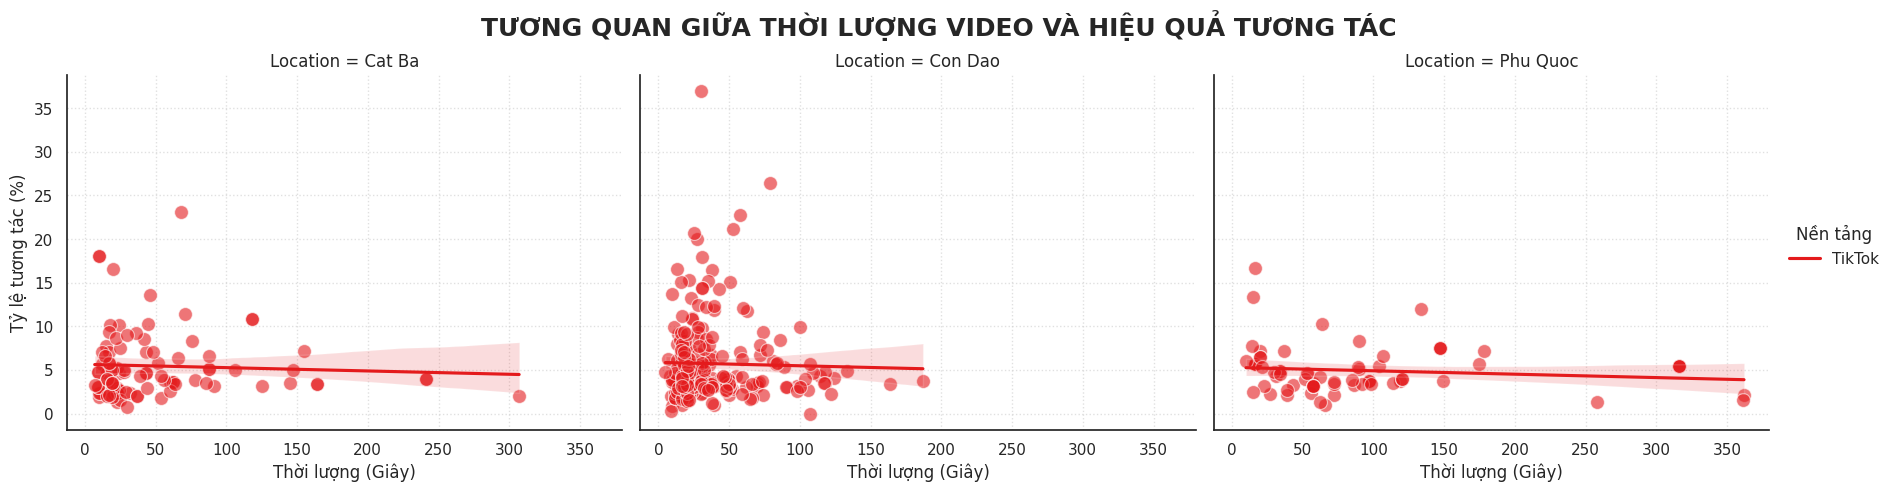

In [ ]:
# 1. Chuẩn bị dữ liệu
df = pd.read_csv('merged_data_fixed_date.csv')

# Chuyển đổi Duration sang dạng số (giây) nếu cần
# (Giả sử Duration đã được làm sạch về dạng float/int ở bước trước)
df['Duration'] = pd.to_numeric(df['Duration'], errors='coerce')
df = df.dropna(subset=['Duration', 'Engagement_Rate'])

# Lọc bỏ các giá trị ngoại lai (outliers) để biểu đồ dễ nhìn hơn
# Ví dụ: Chỉ lấy video dưới 20 phút (1200s) và Engagement Rate dưới 50%
df_plot = df[(df['Duration'] < 1200) & (df['Engagement_Rate'] < 50)].copy()

# 2. Vẽ biểu đồ
plt.figure(figsize=(16, 8))
sns.set_theme(style="white")

# Sử dụng FacetGrid để chia biểu đồ theo 3 địa điểm
g = sns.FacetGrid(df_plot, col="Location", hue="Platform", height=5, aspect=1.2, palette='Set1')
g.map(sns.scatterplot, "Duration", "Engagement_Rate", alpha=0.6, s=100)

# Thêm đường hồi quy (regression line) để thấy rõ xu hướng tương quan
g.map(sns.regplot, "Duration", "Engagement_Rate", scatter=False)

# 3. Định dạng và chú thích
g.add_legend(title="Nền tảng")
g.set_axis_labels("Thời lượng (Giây)", "Tỷ lệ tương tác (%)")
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle('TƯƠNG QUAN GIỮA THỜI LƯỢNG VIDEO VÀ HIỆU QUẢ TƯƠNG TÁC', fontsize=18, fontweight='bold')

# Thêm lưới cho các biểu đồ con
for ax in g.axes.flat:
    ax.grid(True, linestyle=':', alpha=0.6)

plt.show()

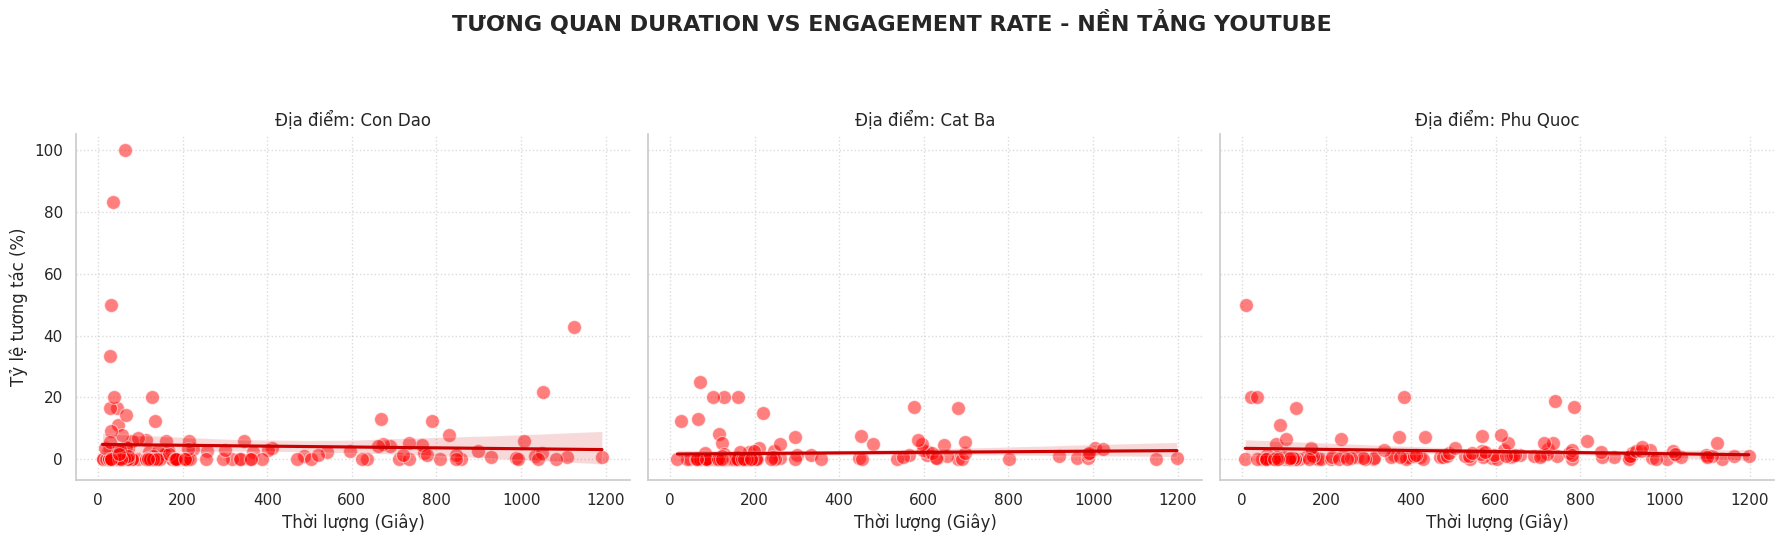

In [ ]:
#1. Hàm giải mã thời lượng YouTube (MM:SS hoặc HH:MM:SS -> Giây)
def parse_yt_duration(val):
    if pd.isna(val) or val == 'N/A' or val == '': return None
    try:
        if isinstance(val, (int, float)): return float(val)
        parts = str(val).split(':')
        if len(parts) == 2: # MM:SS
            return int(parts[0]) * 60 + int(parts[1])
        if len(parts) == 3: # HH:MM:SS
            return int(parts[0]) * 3600 + int(parts[1]) * 60 + int(parts[2])
        return float(val)
    except:
        return None

# 2. Đọc và lọc riêng YouTube
df = pd.read_csv('merged_data_fixed_date.csv')
yt_df = df[df['Platform'] == 'YouTube'].copy()

# Chuyển đổi cột Duration
yt_df['Duration_Sec'] = yt_df['Duration'].apply(parse_yt_duration)

# Lọc bỏ dữ liệu trống và giới hạn để biểu đồ tập trung (ví dụ: video dưới 20 phút)
yt_df = yt_df.dropna(subset=['Duration_Sec', 'Engagement_Rate'])
yt_df = yt_df[yt_df['Duration_Sec'] < 1200]

# 3. Vẽ biểu đồ tương quan cho YouTube
sns.set_theme(style="whitegrid")
g = sns.FacetGrid(yt_df, col="Location", height=5, aspect=1.2)

# Vẽ điểm dữ liệu và đường hồi quy màu cam đặc trưng của YouTube (hoặc đỏ đô)
g.map(sns.scatterplot, "Duration_Sec", "Engagement_Rate", color="#FF0000", alpha=0.5, s=100)
g.map(sns.regplot, "Duration_Sec", "Engagement_Rate", scatter=False, color="#CC0000")

# Định dạng nhãn và tiêu đề
g.set_axis_labels("Thời lượng (Giây)", "Tỷ lệ tương tác (%)")
g.set_titles("Địa điểm: {col_name}")
g.fig.suptitle('TƯƠNG QUAN DURATION VS ENGAGEMENT RATE - NỀN TẢNG YOUTUBE',
               fontsize=16, fontweight='bold', y=1.08)

# Thêm lưới
for ax in g.axes.flat:
    ax.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

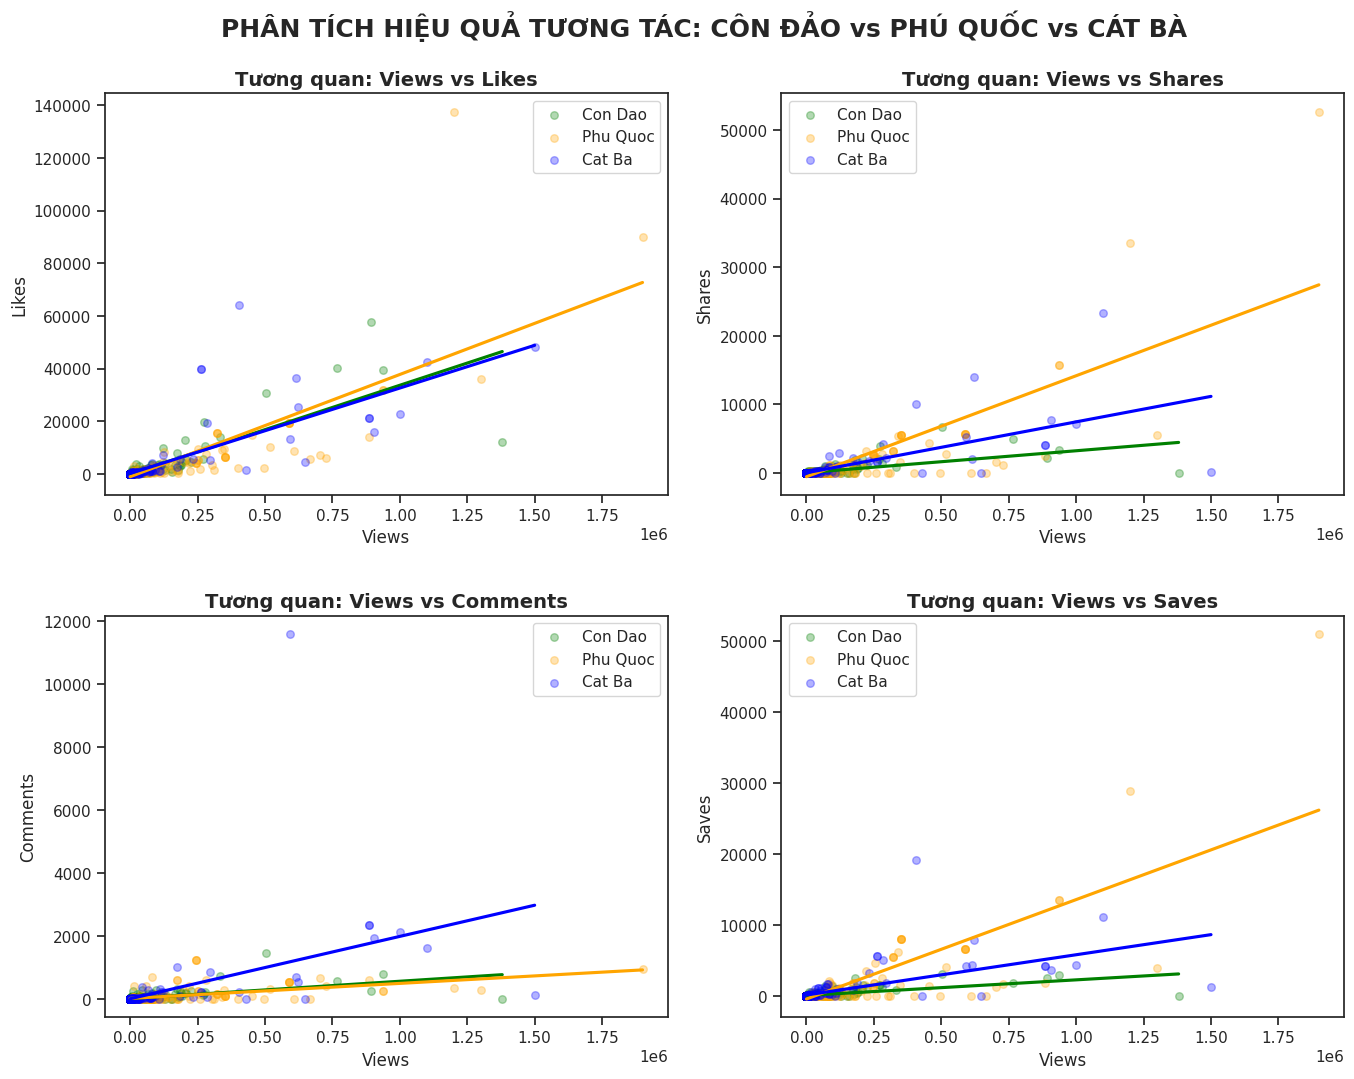

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Đọc dữ liệu
df = pd.read_csv('merged_data_fixed_date.csv')

# 2. Thiết lập khung biểu đồ (2 hàng x 2 cột)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
plt.subplots_adjust(hspace=0.3, wspace=0.2)

metrics = ['Likes', 'Shares', 'Comments', 'Saves']
colors = {'Con Dao': 'green', 'Phu Quoc': 'orange', 'Cat Ba': 'blue'}

# 3. Vẽ biểu đồ tương quan cho từng chỉ số
for i, col in enumerate(metrics):
    ax = axes[i//2, i%2]
    # Vẽ các điểm dữ liệu và đường hồi quy cho mỗi địa điểm
    for loc, color in colors.items():
        subset = df[df['Location'] == loc]
        sns.regplot(data=subset, x='Views', y=col, ax=ax,
                    label=loc, color=color,
                    scatter_kws={'alpha':0.3, 's':30}, # Làm mờ điểm để dễ nhìn
                    ci=None) # Tắt dải tin cậy để biểu đồ thoáng hơn

    ax.set_title(f'Tương quan: Views vs {col}', fontsize=14, fontweight='bold')
    ax.legend()

plt.suptitle('PHÂN TÍCH HIỆU QUẢ TƯƠNG TÁC: CÔN ĐẢO vs PHÚ QUỐC vs CÁT BÀ',
             fontsize=18, fontweight='bold', y=0.95)
plt.show()

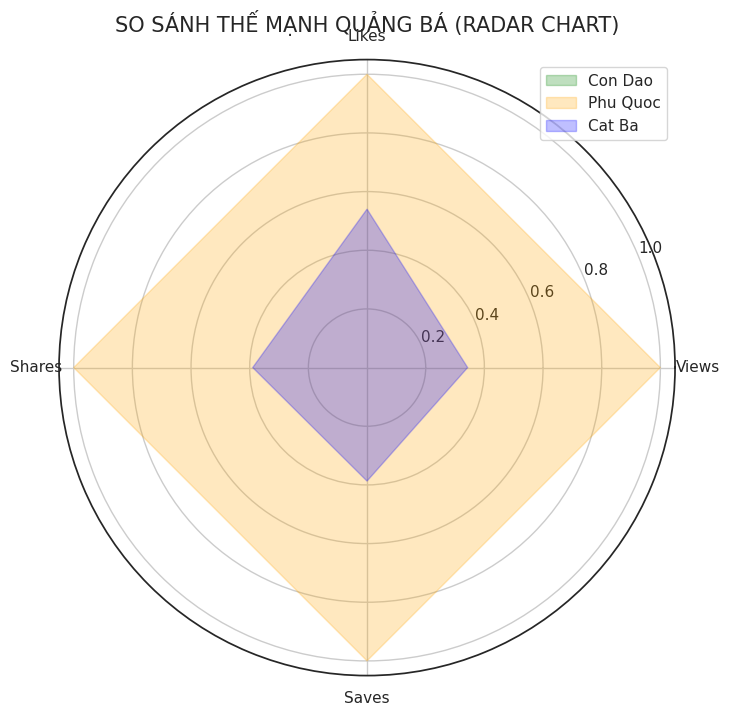

In [ ]:


# Gom nhóm dữ liệu trung bình
summary = df.groupby('Location')[['Views', 'Likes', 'Shares', 'Saves']].mean()
# Chuẩn hóa dữ liệu về thang đo 0-1 để vẽ radar
summary_norm = (summary - summary.min()) / (summary.max() - summary.min())

labels=np.array(['Views', 'Likes', 'Shares', 'Saves'])
stats_cd = summary_norm.loc['Con Dao'].values
stats_pq = summary_norm.loc['Phu Quoc'].values
stats_cb = summary_norm.loc['Cat Ba'].values

angles=np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
stats_cd=np.concatenate((stats_cd,[stats_cd[0]]))
stats_pq=np.concatenate((stats_pq,[stats_pq[0]]))
stats_cb=np.concatenate((stats_cb,[stats_cb[0]]))
angles=np.concatenate((angles,[angles[0]]))

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.fill(angles, stats_cd, color='green', alpha=0.25, label='Con Dao')
ax.fill(angles, stats_pq, color='orange', alpha=0.25, label='Phu Quoc')
ax.fill(angles, stats_cb, color='blue', alpha=0.25, label='Cat Ba')
ax.set_thetagrids(np.degrees(angles[:-1]), labels)
plt.title('SO SÁNH THẾ MẠNH QUẢNG BÁ (RADAR CHART)', fontsize=15, pad=20)
plt.legend()
plt.show()